In [1]:
import os
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torchvision.transforms as T

# Diffusers & PEFT imports
from diffusers import AutoencoderKL, UNet2DConditionModel
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig, get_peft_model

# 1. Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# 2. Base model ID (Stable Diffusion 1.5 is standard for industrial/realistic fine-tuning)
model_id = "runwayml/stable-diffusion-v1-5"

print("Loading base models...")

# A. Tokenizer and Text Encoder (Translates .txt captions into math vectors)
tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder").to(device)

# B. VAE (Compresses images into the latent space)
vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae").to(device)

# C. U-Net (The actual "Generator" that removes noise)
unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet").to(device)

# 3. FREEZE BASE MODELS
# We keep VAE, text_encoder and unet frozen to preserve their learned capabilities
vae.requires_grad_(False) 
text_encoder.requires_grad_(False)
unet.requires_grad_(False)

print("Base models loaded and frozen successfully.")

c:\ProgramData\anaconda3\envs\diffusion_models\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Training on device: cuda
Loading base models...


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 12246.87it/s]
CLIPTextModel LOAD REPORT from: runwayml/stable-diffusion-v1-5
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
c:\ProgramData\anaconda3\envs\diffusion_models\lib\site-packages\huggingface_hub\utils\_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Base models loaded and frozen successfully.


In [2]:
# 1. Configure LoRA hyperparameters
lora_config = LoraConfig(
    r=8,                     # Rank: Size of the new "brain" (8 or 16 is ideal for textures/defects)
    lora_alpha=16,           # Scaling factor
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"] # Injecting into U-Net's attention layers
)

# 2. Inject LoRA into the frozen U-Net
unet = get_peft_model(unet, lora_config)

# Print the amount of parameters we are actually training (Usually < 0.1%)
unet.print_trainable_parameters()

# 3. Setup the Optimizer (It will only update the LoRA weights)
# Learning rate for LoRA is usually higher than full fine-tuning (e.g., 1e-4)
optimizer = torch.optim.AdamW(unet.parameters(), lr=1e-4)

trainable params: 1,594,368 || all params: 861,115,332 || trainable%: 0.1852


In [3]:
class CastingDataset(Dataset):
    """
    Custom Dataset to load casting images alongside their text captions.
    """
    def __init__(self, image_dir, tokenizer, size=512):
        self.image_dir = image_dir
        self.tokenizer = tokenizer
        
        # List only the .txt files (each has a corresponding image)
        self.text_files = [f for f in os.listdir(image_dir) if f.endswith('.txt')]
        
        # Transformations for Stable Diffusion (Needs range [-1, 1])
        self.transform = T.Compose([
            T.Resize((size, size)),
            T.ToTensor(),
            T.Normalize([0.5], [0.5]) 
        ])

    def __len__(self):
        return len(self.text_files)

    def __getitem__(self, idx):
        # 1. Read the caption text
        txt_name = self.text_files[idx]
        with open(os.path.join(self.image_dir, txt_name), 'r') as f:
            text = f.read().strip()
            
        # 2. Tokenize the text
        text_inputs = self.tokenizer(
            text, 
            padding="max_length", 
            max_length=self.tokenizer.model_max_length, 
            truncation=True, 
            return_tensors="pt"
        )
        
        # 3. Read the corresponding image
        img_name = txt_name.replace('.txt', '.jpeg') 
        img_path = os.path.join(self.image_dir, img_name)
        
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)
        
        return {
            "pixel_values": image, 
            "input_ids": text_inputs.input_ids.squeeze()
        }

# ==============================================================================
# Instantiate Datasets and Dataloader
# ==============================================================================

PATH_OK = "../data/processed/casting/casting_512x512/ok_front/"
PATH_DEF = "../data/processed/casting/casting_512x512/def_front/"

# Create individual datasets
dataset_ok = CastingDataset(PATH_OK, tokenizer)
dataset_def = CastingDataset(PATH_DEF, tokenizer)

# Merge them so the model learns both classes simultaneously
full_dataset = ConcatDataset([dataset_ok, dataset_def])

# Create the dataloader
# Batch size is kept small (2 or 4) to avoid VRAM Out-Of-Memory errors on standard GPUs
train_dataloader = DataLoader(full_dataset, batch_size=2, shuffle=True)

print(f"Total images ready for training: {len(full_dataset)}")
print(f"Total batches per epoch: {len(train_dataloader)}")

Total images ready for training: 1300
Total batches per epoch: 650


In [4]:
import torch.nn.functional as F
from diffusers import DDPMScheduler
from tqdm.auto import tqdm

# 1. Load the Noise Scheduler (Controls how noise is added during training)
noise_scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

# 2. Training Hyperparameters
EPOCHS = 50 # Start with 50-100 to see how it converges
global_step = 0

# Set U-Net to training mode (Only the injected LoRA layers will actually train)
unet.train()

print(f"Starting training for {EPOCHS} epochs...")

for epoch in range(EPOCHS):
    # Progress bar for visual feedback
    progress_bar = tqdm(total=len(train_dataloader), desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    epoch_loss = 0.0

    for batch in train_dataloader:
        # A. Convert images to latent space using VAE
        with torch.no_grad():
            latents = vae.encode(batch["pixel_values"].to(device)).latent_dist.sample()
            latents = latents * vae.config.scaling_factor # Standard SD scaling
            
            # Get text embeddings from the prompt
            encoder_hidden_states = text_encoder(batch["input_ids"].to(device))[0]

        # B. Sample random noise to add to the latents
        noise = torch.randn_like(latents)
        batch_size = latents.shape[0]

        # C. Sample a random timestep for each image in the batch
        timesteps = torch.randint(
            0, noise_scheduler.config.num_train_timesteps, (batch_size,), device=latents.device
        ).long()

        # D. Add noise to the latents (Forward Diffusion Process)
        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        # E. Predict the noise residual (The U-Net tries to guess the noise we added)
        # We pass the noisy image, the time step, and the text condition
        model_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample

        # F. Calculate Loss (Mean Squared Error between predicted and actual noise)
        loss = F.mse_loss(model_pred.float(), noise.float(), reduction="mean")

        # G. Backpropagation (Update LoRA weights)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad() # Clean gradients for next step

        # Update progress bar
        progress_bar.update(1)
        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})
        
        epoch_loss += loss.item()
        global_step += 1
        
    # Print average loss per epoch
    avg_loss = epoch_loss / len(train_dataloader)
    print(f"Epoch {epoch+1} finished | Average Loss: {avg_loss:.4f}")

# ==============================================================================
# 3. Save the trained LoRA weights!
# ==============================================================================
save_path = "../models/sd_lora_casting"
unet.save_pretrained(save_path)
print(f"✅ Training complete! LoRA weights saved safely at: {save_path}")

c:\ProgramData\anaconda3\envs\diffusion_models\lib\site-packages\huggingface_hub\utils\_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Starting training for 50 epochs...


Epoch 1/50: 100%|██████████| 650/650 [03:38<00:00,  2.98it/s, loss=0.0089]

Epoch 1 finished | Average Loss: 0.1210


Epoch 1/50: 100%|██████████| 650/650 [03:38<00:00,  2.97it/s, loss=0.0089]


...

Epoch 48 finished | Average Loss: 0.1122


Epoch 49/50: 100%|██████████| 650/650 [03:36<00:00,  3.02it/s, loss=0.0722]

Epoch 49 finished | Average Loss: 0.1069


Epoch 49/50: 100%|██████████| 650/650 [03:36<00:00,  3.00it/s, loss=0.0722]


Epoch 50 finished | Average Loss: 0.1085
✅ Training complete! LoRA weights saved safely at: ../models/sd_lora_casting


Loading SD Pipeline and LoRA weights...


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 3135.06it/s]
CLIPTextModel LOAD REPORT from: C:\Users\estiv\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading pipeline components...:  71%|███████▏  | 5/7 [00:01<00:00,  2.94it/s]

Loading weights: 100%|██████████| 396/396 [00:00<00:00, 2758.07it/s]
StableDiffusionSafetyChecker LOAD REPORT from: C:\Users\estiv\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5\snapshots\451f4fe16113bff5a5d2269ed5ad43b0592e9a14\safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--

Generating 5 OK condition images...


100%|██████████| 30/30 [00:01<00:00, 21.86it/s]


Generating 5 Defective condition images...


100%|██████████| 30/30 [00:01<00:00, 22.31it/s]


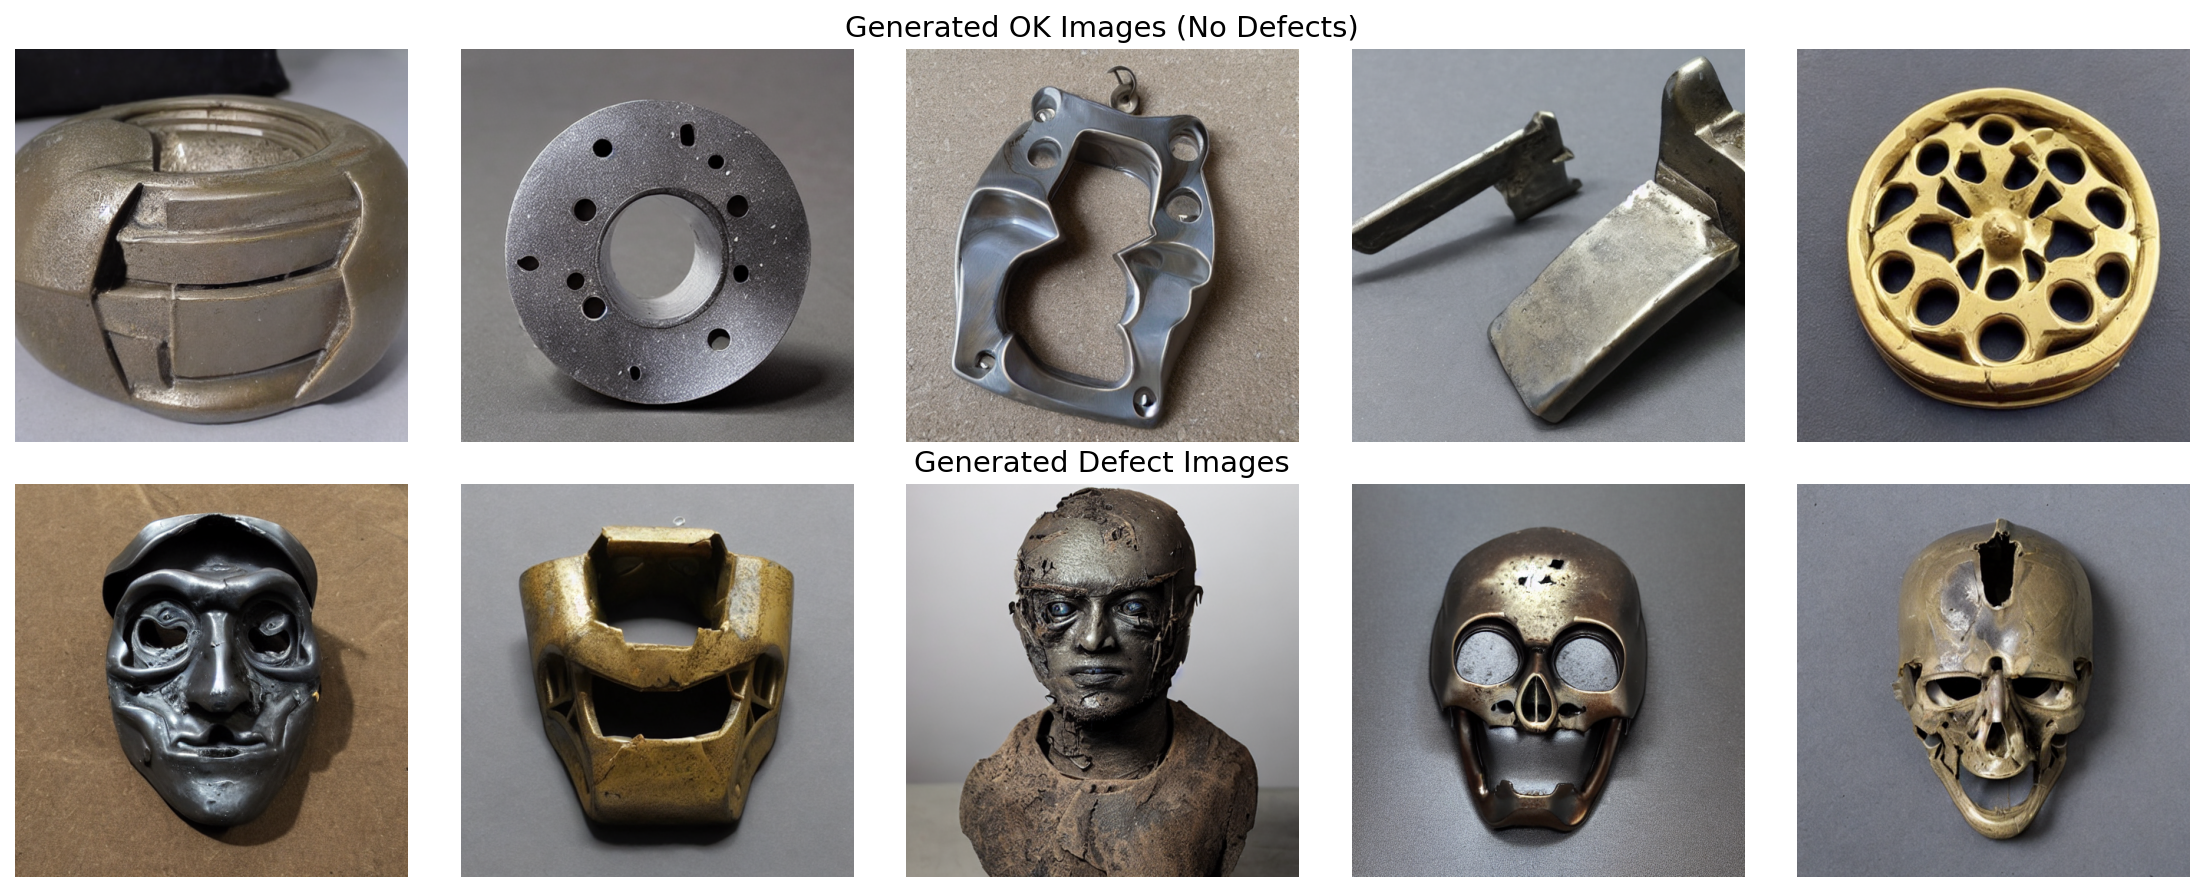

In [5]:
import torch
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline

# 1. Load the Pipeline and LoRA weights
model_id = "runwayml/stable-diffusion-v1-5"
device = "cuda"

print("Loading SD Pipeline and LoRA weights...")
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16).to(device)

# Load your custom trained LoRA
pipe.load_lora_weights("../models/sd_lora_casting")

# Disable safety checker to avoid black images on industrial textures (optional but recommended for custom datasets)
pipe.safety_checker = None 

# 2. Define Prompts (Trigger Words)
prompt_ok = "photo of TOK_CASTING piece, ok condition, clean perfect metal"
prompt_def = "photo of TOK_CASTING piece, defective condition, industrial reject, damaged metal"
negative_prompt = "blurry, low quality, distorted, background noise"

# 3. Generate 5 OK images
print("Generating 5 OK condition images...")
images_ok = []
for i in range(5):
    img = pipe(prompt=prompt_ok, negative_prompt=negative_prompt, num_inference_steps=30, guidance_scale=7.5).images[0]
    images_ok.append(img)

# 4. Generate 5 Defective images
print("Generating 5 Defective condition images...")
images_def = []
for i in range(5):
    img = pipe(prompt=prompt_def, negative_prompt=negative_prompt, num_inference_steps=30, guidance_scale=7.5).images[0]
    images_def.append(img)

# 5. Plot the 2x5 Grid
fig, axes = plt.subplots(2, 5, figsize=(15, 6), dpi=150)

# Plot OK on top
for i in range(5):
    axes[0, i].imshow(images_ok[i])
    axes[0, i].axis('off')
    if i == 2:
        axes[0, i].set_title("Generated OK Images (No Defects)", fontsize=14)

# Plot Defects on bottom
for i in range(5):
    axes[1, i].imshow(images_def[i])
    axes[1, i].axis('off')
    if i == 2:
        axes[1, i].set_title("Generated Defect Images", fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt

print("Calculating text embeddings for arithmetic progression...")

# 1. Helper function to get Text Embeddings directly from the prompt
def get_text_embeddings(prompt, pipeline):
    text_inputs = pipeline.tokenizer(
        prompt, 
        padding="max_length", 
        max_length=pipeline.tokenizer.model_max_length, 
        truncation=True, 
        return_tensors="pt"
    )
    with torch.no_grad():
        embeddings = pipeline.text_encoder(text_inputs.input_ids.to(pipeline.device))[0]
    return embeddings

# Get embeddings for OK, DEFECT, and NEGATIVE prompt
embed_ok = get_text_embeddings(prompt_ok, pipe)
embed_def = get_text_embeddings(prompt_def, pipe)
embed_negative = get_text_embeddings(negative_prompt, pipe)

# 2. Define Alphas for progression (0.0 = 100% OK, 1.0 = 100% Defect)
alphas = [0.0, 0.25, 0.5, 0.75, 1.0]
images_progression = []

# 3. FIX THE LATENT NOISE (Seed)
# This guarantees that the background and the basic shape of the piece stay EXACTLY the same.
# Only the texture/defect will change as we inject the new text embedding.
generator = torch.Generator(device="cuda").manual_seed(42) # You can change 42 to explore different base pieces
starting_latents = torch.randn(
    (1, pipe.unet.config.in_channels, 512 // 8, 512 // 8),
    generator=generator,
    device="cuda",
    dtype=torch.float16
)

print("Generating progression...")

# 4. Interpolate and Generate
for alpha in alphas:
    # Linear Interpolation of the concepts
    interp_embeds = (1.0 - alpha) * embed_ok + alpha * embed_def
    
    # Generate image using the mathematical embeddings instead of text strings
    img = pipe(
        prompt_embeds=interp_embeds,
        negative_prompt_embeds=embed_negative,
        latents=starting_latents.clone(), # VERY IMPORTANT to clone so the noise doesn't degrade
        num_inference_steps=30,
        guidance_scale=7.5
    ).images[0]
    
    images_progression.append(img)

# 5. Plot the 1x5 Progression
fig, axes = plt.subplots(1, 5, figsize=(15, 4), dpi=150)

for i, alpha in enumerate(alphas):
    axes[i].imshow(images_progression[i])
    axes[i].axis('off')
    axes[i].set_title(r"$\alpha = {}$".format(alpha), fontsize=12)

plt.suptitle(r"Text Embedding Arithmetic: OK $\rightarrow$ Progressive Defect", fontsize=16)
plt.tight_layout()
plt.show()